# 📊 Telco Customer Churn Analysis

**Author:** Vusal Mammadzade · **GitHub:** [memmedzadev81-max](https://github.com/memmedzadev81-max)

A telecom company is losing customers (**churn**). Every lost customer = lost monthly revenue.
This project answers one business question:

> **Which customers leave, and why — and what can the company do to keep them?**

We use real data on **7,043 customers** and go through the full analyst workflow:
Data Cleaning → EDA → Statistics → Statistical Tests → Business Insights.


## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = {"No": "#4C9F70", "Yes": "#D9534F"}

df = pd.read_csv("../data/Telco-Customer-Churn.csv")
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Cleaning

Three problems to fix before any analysis:
1. `TotalCharges` is stored as **text** and has 11 empty values (brand-new customers, tenure = 0).
2. `SeniorCitizen` is coded as 0/1 — hard to read.
3. `customerID` is just an identifier, useless for analysis.


In [2]:
# 1) TotalCharges text -> number; blanks belong to tenure=0 -> fill with 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Empty TotalCharges:", df["TotalCharges"].isna().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 2) Make SeniorCitizen readable
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# 3) Drop ID
df = df.drop(columns=["customerID"])

print("Duplicate rows:", df.duplicated().sum())
print("Missing values total:", df.isna().sum().sum())

Empty TotalCharges: 11
Duplicate rows: 22
Missing values total: 0


## 3. Exploratory Data Analysis (EDA)

First, the big picture: how many customers actually churn?

Overall churn rate: 26.5%


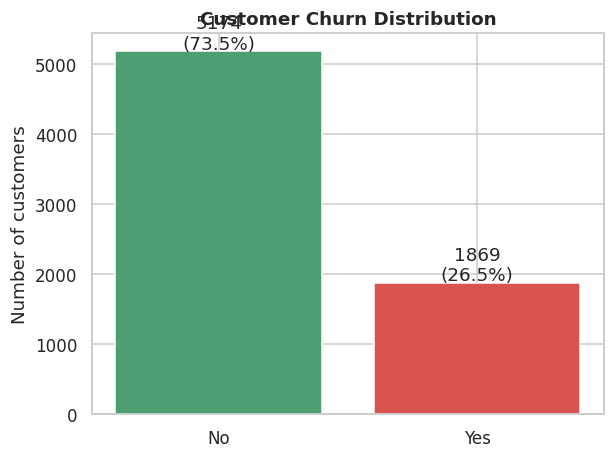

In [3]:
churn_rate = (df["Churn"] == "Yes").mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")

counts = df["Churn"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(counts.index, counts.values, color=[PALETTE["No"], PALETTE["Yes"]])
ax.set_title("Customer Churn Distribution", weight="bold")
ax.set_ylabel("Number of customers")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+40, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
plt.show()

**Insight:** ~26.5% of customers churn. This is an *imbalanced* problem — most customers stay,
so we must look at **which subgroups** churn more than average (26.5%).

In [4]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


### 3.1 How long do customers stay? (Tenure)

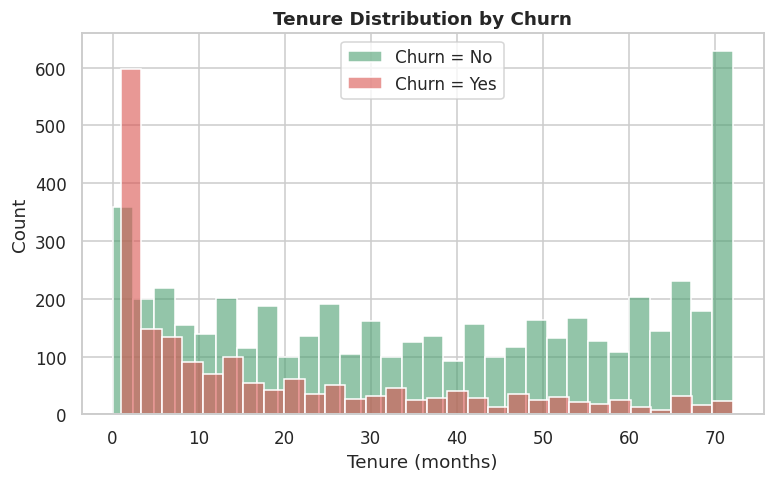

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for label in ["No", "Yes"]:
    sns.histplot(df[df["Churn"]==label]["tenure"], bins=30,
                 label=f"Churn = {label}", color=PALETTE[label], alpha=0.6, ax=ax)
ax.set_title("Tenure Distribution by Churn", weight="bold")
ax.set_xlabel("Tenure (months)"); ax.legend()
plt.show()

**Insight:** Churned customers are concentrated in the **first months**. New customers are the most fragile.

### 3.2 Do churned customers pay more? (Monthly Charges)

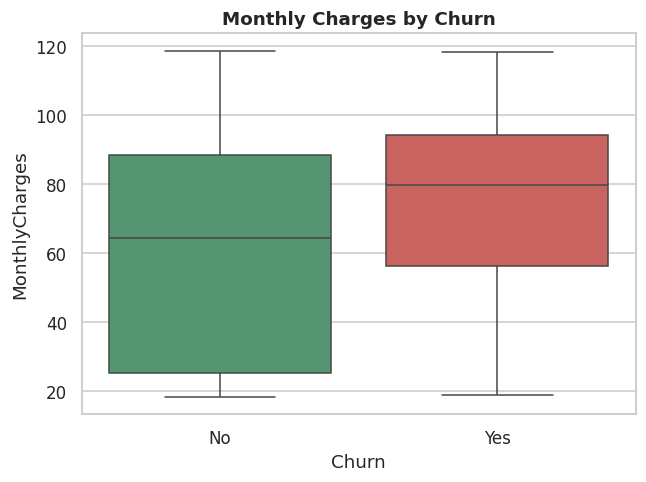

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn",
            palette=PALETTE, legend=False, ax=ax)
ax.set_title("Monthly Charges by Churn", weight="bold")
plt.show()

**Insight:** Churned customers tend to have **higher monthly bills** — price sensitivity matters.

### 3.3 Churn rate by Contract type

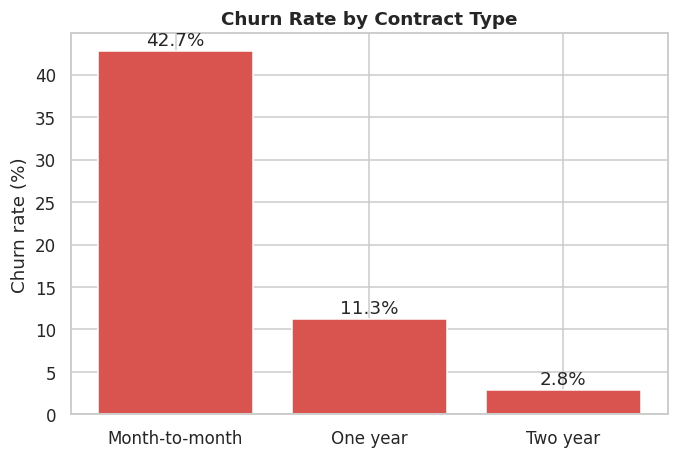

In [7]:
def churn_rate_by(col):
    return df.groupby(col)["Churn"].apply(lambda s: (s=="Yes").mean()*100)

fig, ax = plt.subplots(figsize=(7, 4.5))
cr = churn_rate_by("Contract").sort_values(ascending=False)
bars = ax.bar(cr.index, cr.values, color="#D9534F")
ax.set_title("Churn Rate by Contract Type", weight="bold"); ax.set_ylabel("Churn rate (%)")
for b, v in zip(bars, cr.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.7, f"{v:.1f}%", ha="center")
plt.show()

**Insight (biggest finding):** Month-to-month customers churn at **42.7%**, vs only **2.8%** for 2-year contracts. Contract length is the strongest protector against churn.

### 3.4 Churn rate by Internet Service

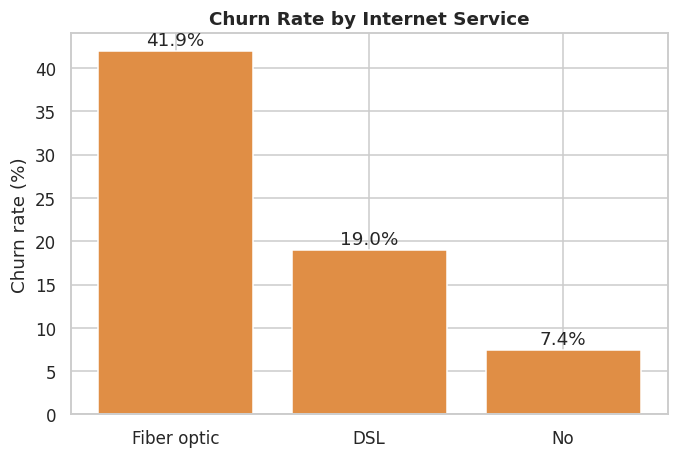

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
cr = churn_rate_by("InternetService").sort_values(ascending=False)
bars = ax.bar(cr.index, cr.values, color="#E08E45")
ax.set_title("Churn Rate by Internet Service", weight="bold"); ax.set_ylabel("Churn rate (%)")
for b, v in zip(bars, cr.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.7, f"{v:.1f}%", ha="center")
plt.show()

**Insight:** Fiber optic customers churn at **41.9%** — surprisingly high. Likely a price/expectation problem worth investigating.

### 3.5 Churn rate by Payment Method

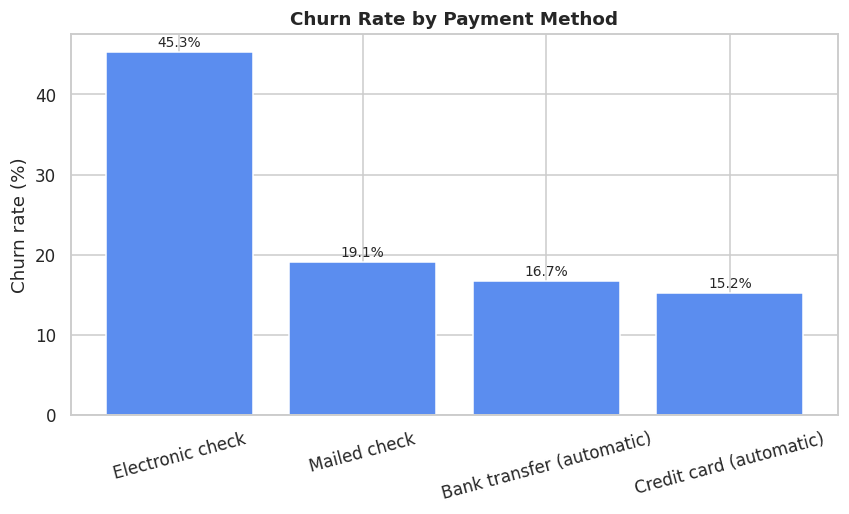

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
cr = churn_rate_by("PaymentMethod").sort_values(ascending=False)
bars = ax.bar(cr.index, cr.values, color="#5B8DEF")
ax.set_title("Churn Rate by Payment Method", weight="bold"); ax.set_ylabel("Churn rate (%)")
plt.xticks(rotation=15)
for b, v in zip(bars, cr.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.7, f"{v:.1f}%", ha="center", fontsize=9)
plt.show()

**Insight:** Electronic-check users churn at **45.3%** — by far the highest. This payment type flags at-risk customers.

### 3.6 Correlation between numeric variables

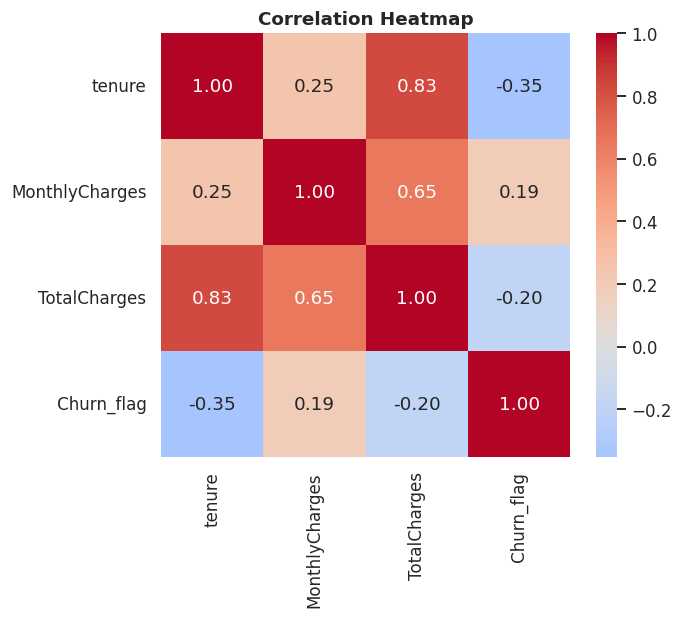

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
num = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
num["Churn_flag"] = (df["Churn"] == "Yes").astype(int)
sns.heatmap(num.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap", weight="bold")
plt.show()

**Insight:** `tenure` and `TotalCharges` are strongly correlated (r = 0.83) — logical, longer stay = more total paid. `tenure` is *negatively* related to churn.

## 4. Statistical Tests

EDA shows *patterns*. Statistical tests confirm whether those patterns are **real or just random noise**.
Rule: if **p-value < 0.05**, the relationship is statistically significant.


### 4.1 Chi-Square Test (category vs category)
Used when both variables are categorical (e.g. *Contract type* vs *Churn*).
**Cramér's V** measures how strong the link is (0 = none, 1 = perfect).

In [11]:
def chi_square(col):
    table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    n = table.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    return chi2, p, cramers_v

print(f"{'Variable':<18}{'chi2':>10}{'p-value':>12}{'CramersV':>10}  Result")
for col in ["Contract","InternetService","PaymentMethod","TechSupport","OnlineSecurity"]:
    chi2, p, v = chi_square(col)
    sig = "SIGNIFICANT" if p < 0.05 else "not sig."
    print(f"{col:<18}{chi2:>10.1f}{p:>12.1e}{v:>10.3f}  {sig}")

Variable                chi2     p-value  CramersV  Result
Contract              1184.6    5.9e-258     0.410  SIGNIFICANT
InternetService        732.3    9.6e-160     0.322  SIGNIFICANT
PaymentMethod          648.1    3.7e-140     0.303  SIGNIFICANT
TechSupport            828.2    1.4e-180     0.343  SIGNIFICANT
OnlineSecurity         850.0    2.7e-185     0.347  SIGNIFICANT


**Insight:** All five are highly significant. **Contract** has the strongest association with churn (Cramér's V = 0.41).

### 4.2 T-Test (compare a number between two groups)
Do churned vs non-churned customers differ in **Monthly Charges** and **tenure**?

In [12]:
for col in ["MonthlyCharges", "tenure"]:
    yes = df[df["Churn"]=="Yes"][col]
    no  = df[df["Churn"]=="No"][col]
    t, p = stats.ttest_ind(yes, no, equal_var=False)
    print(f"{col}: mean(churn)={yes.mean():.1f}, mean(stay)={no.mean():.1f}, "
          f"t={t:.1f}, p={p:.1e} -> {'SIGNIFICANT' if p<0.05 else 'not sig.'}")

MonthlyCharges: mean(churn)=74.4, mean(stay)=61.3, t=18.4, p=8.6e-73 -> SIGNIFICANT
tenure: mean(churn)=18.0, mean(stay)=37.6, t=-34.8, p=1.2e-232 -> SIGNIFICANT


**Insight:** Churned customers pay **more per month** (74.4 vs 61.3) and stay **far shorter** (18 vs 38 months). Both differences are real (p < 0.05).

### 4.3 ANOVA (compare a number across 3+ groups)
Do average Monthly Charges differ across the three contract types?

In [13]:
groups = [g["MonthlyCharges"].values for _, g in df.groupby("Contract")]
f, p = stats.f_oneway(*groups)
print(f"ANOVA: F={f:.2f}, p={p:.1e} -> {'SIGNIFICANT' if p<0.05 else 'not sig.'}")

ANOVA: F=20.83, p=9.6e-10 -> SIGNIFICANT


### 4.4 Pearson Correlation (relationship between two numbers)

In [14]:
r, p = stats.pearsonr(df["tenure"], df["TotalCharges"])
print(f"tenure vs TotalCharges: r={r:.3f}, p={p:.1e}")

tenure vs TotalCharges: r=0.826, p=0.0e+00


## 5. Key Business Insights

| # | Finding | Number |
|---|---------|--------|
| 1 | Overall churn rate | **26.5%** (1 in 4 customers leaves) |
| 2 | Month-to-month contracts churn far more | **42.7%** vs 2.8% (2-year) |
| 3 | Electronic-check payers are highest risk | **45.3%** churn |
| 4 | Fiber optic customers churn a lot | **41.9%** |
| 5 | No Tech Support / No Online Security → high churn | **~42%** each |
| 6 | Senior citizens churn more | **41.7%** vs 23.6% |
| 7 | Churned customers leave early | avg **18 months** vs 38 |

## 6. Business Recommendations

1. **Lock customers into longer contracts** — offer discounts to move month-to-month users to 1–2 year plans (the single biggest lever, 42.7% → 2.8%).
2. **Fix the electronic-check experience** — push auto-pay (bank/credit card churn is ~15%, half of e-check's 45%).
3. **Onboard new customers hard in the first 6 months** — that is when most churn happens.
4. **Bundle Tech Support & Online Security** — customers without them churn ~3× more.
5. **Review fiber optic pricing/quality** — high revenue but high churn means lost long-term value.

## 7. Tools Used
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `SciPy`
